# EX 5A – Baseball Databank

Same multi-visualization structure as the friend's EX 5A, using Baseball batting and fielding tables.

In [1]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

batting = pd.read_csv(find_data("Batting.csv"))
fielding = pd.read_csv(find_data("Fielding.csv"))

print("Baseball datasets loaded successfully")
print("Batting shape:", batting.shape)
print("Fielding shape:", fielding.shape)
display(batting.head())

Baseball datasets loaded successfully
Batting shape: (101332, 22)
Fielding shape: (170526, 18)


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,0.0,0.0,13.0,8.0,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,5.0,0.0,19.0,3.0,1.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,2.0,2.0,27.0,1.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,3.0,0.0,16.0,6.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN


In [2]:
team_runs = batting.groupby("teamID")["R"].sum().nlargest(10).sort_values()
team_runs

teamID
CHA    78221.0
CLE    81116.0
DET    83222.0
BOS    83309.0
NYA    85715.0
CIN    85970.0
SLN    86003.0
PIT    88658.0
PHI    89959.0
CHN    96003.0
Name: R, dtype: float64

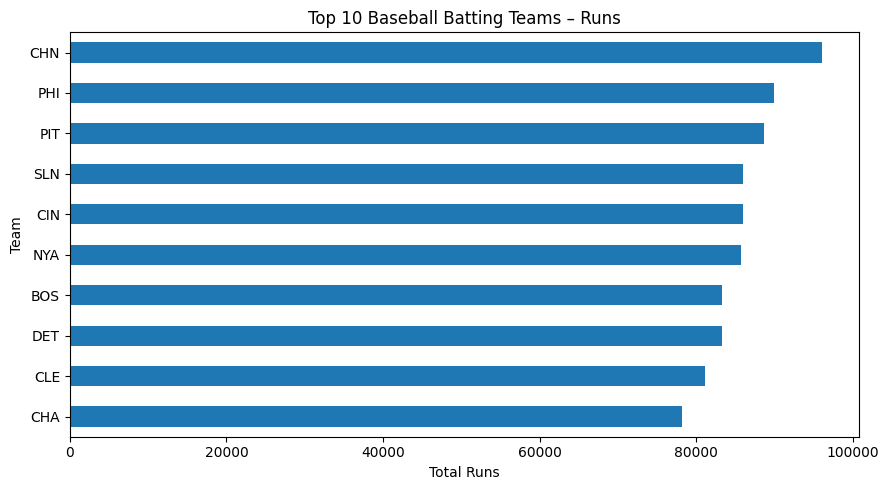

In [3]:
plt.figure(figsize=(9,5))
team_runs.plot(kind="barh")
plt.title("Top 10 Baseball Batting Teams – Runs")
plt.xlabel("Total Runs")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

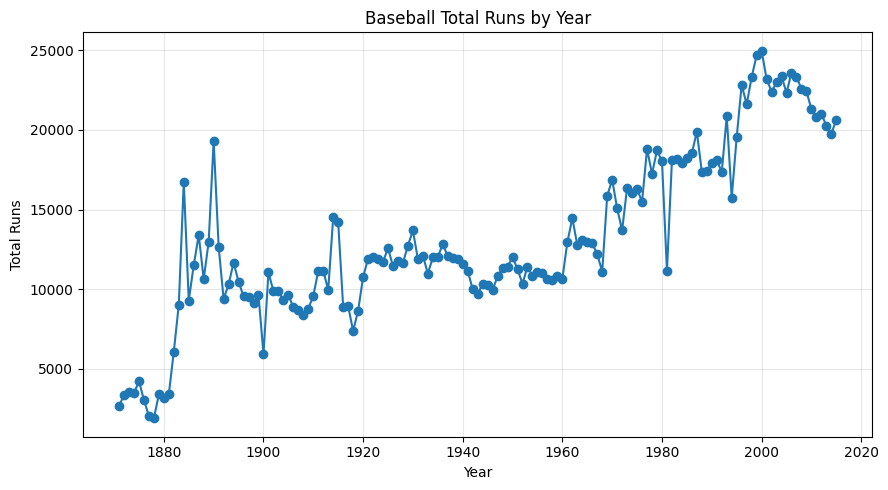

In [4]:
year_runs = batting.groupby("yearID")["R"].sum()
plt.figure(figsize=(9,5))
plt.plot(year_runs.index, year_runs.values, marker="o")
plt.title("Baseball Total Runs by Year")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

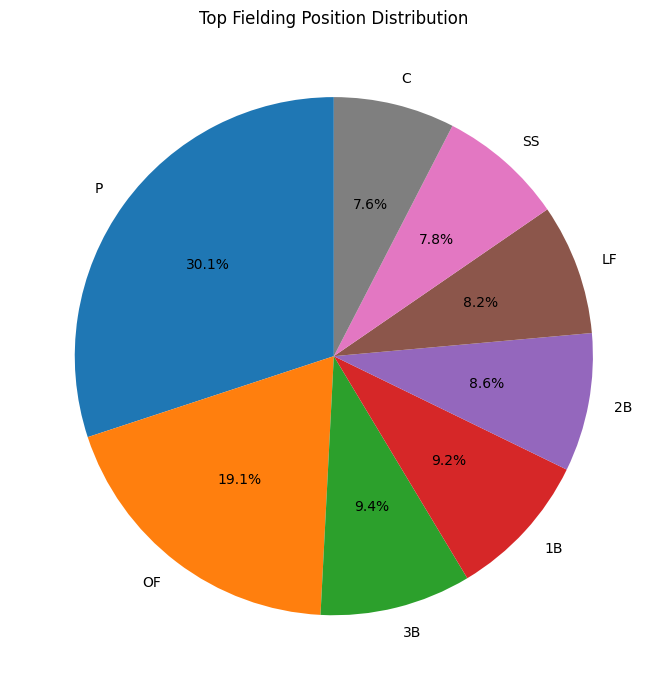

In [5]:
positions = fielding["POS"].value_counts().head(8)
plt.figure(figsize=(7,7))
plt.pie(positions.values, labels=positions.index, autopct="%1.1f%%", startangle=90)
plt.title("Top Fielding Position Distribution")
plt.tight_layout()
plt.show()

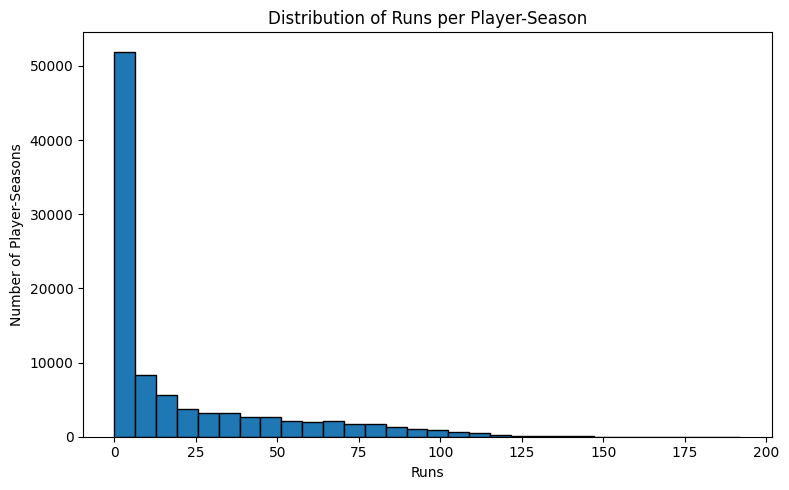

In [6]:
plt.figure(figsize=(8,5))
plt.hist(batting["R"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Runs per Player-Season")
plt.xlabel("Runs")
plt.ylabel("Number of Player-Seasons")
plt.tight_layout()
plt.show()

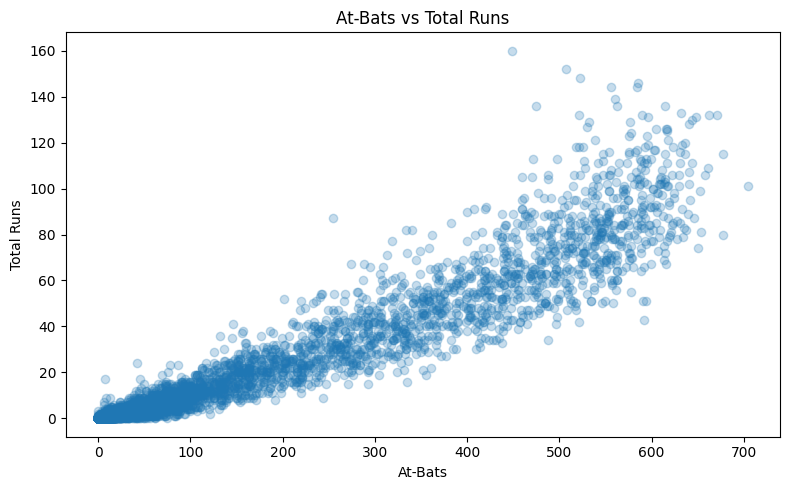

In [7]:
sample = batting.sample(min(5000, len(batting)), random_state=42)
plt.figure(figsize=(8,5))
plt.scatter(sample["AB"], sample["R"], alpha=.25)
plt.title("At-Bats vs Total Runs")
plt.xlabel("At-Bats")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()